<a href="https://colab.research.google.com/github/Abhinav9895/Generative-AI-Internship/blob/main/Day3/unemployed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.lines import lineStyles
from scipy.stats import skew
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [35]:
df=pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


Text(0, 0.5, '')

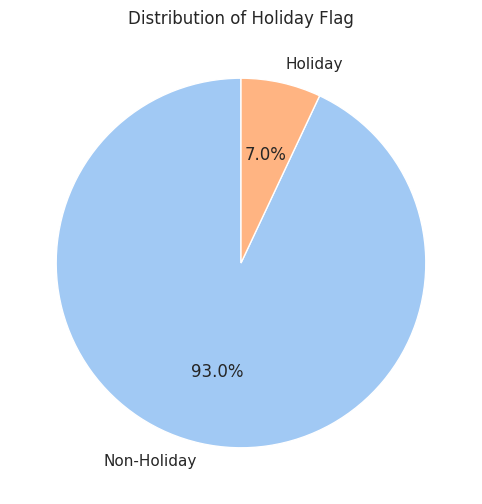

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.figure(figsize=(10,6))

holiday_counts = df['Holiday_Flag'].value_counts()
plt.pie(holiday_counts, labels=['Non-Holiday' if h == 0 else 'Holiday' for h in holiday_counts.index], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Holiday Flag')
plt.ylabel('') # Remove y-label for pie chart

/tmp/ipykernel_585/1071636684.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x="Temperature",y="Weekly_Sales",palette='pastel')


Text(0, 0.5, 'Weekly_Sales')

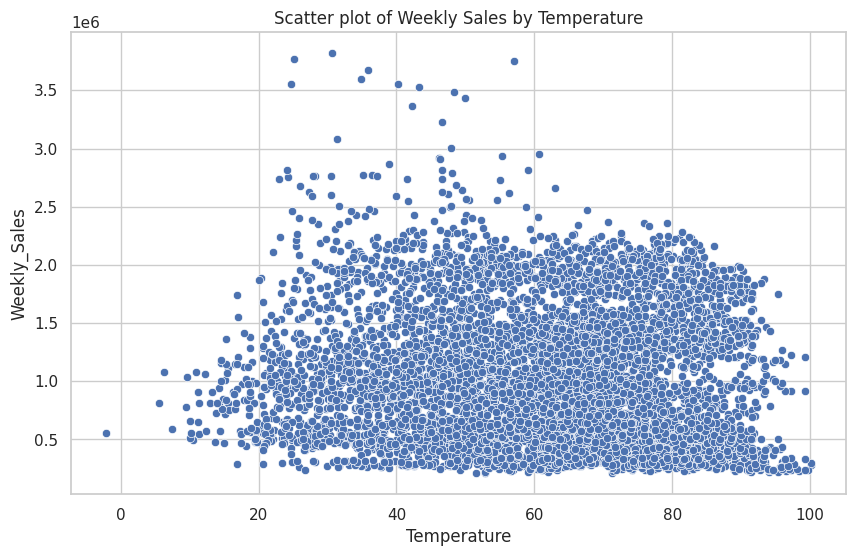

In [37]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Temperature",y="Weekly_Sales",palette='pastel')
plt.title('Scatter plot of Weekly Sales by Temperature')
plt.xlabel('Temperature',fontsize=12)
plt.ylabel('Weekly_Sales',fontsize=12)

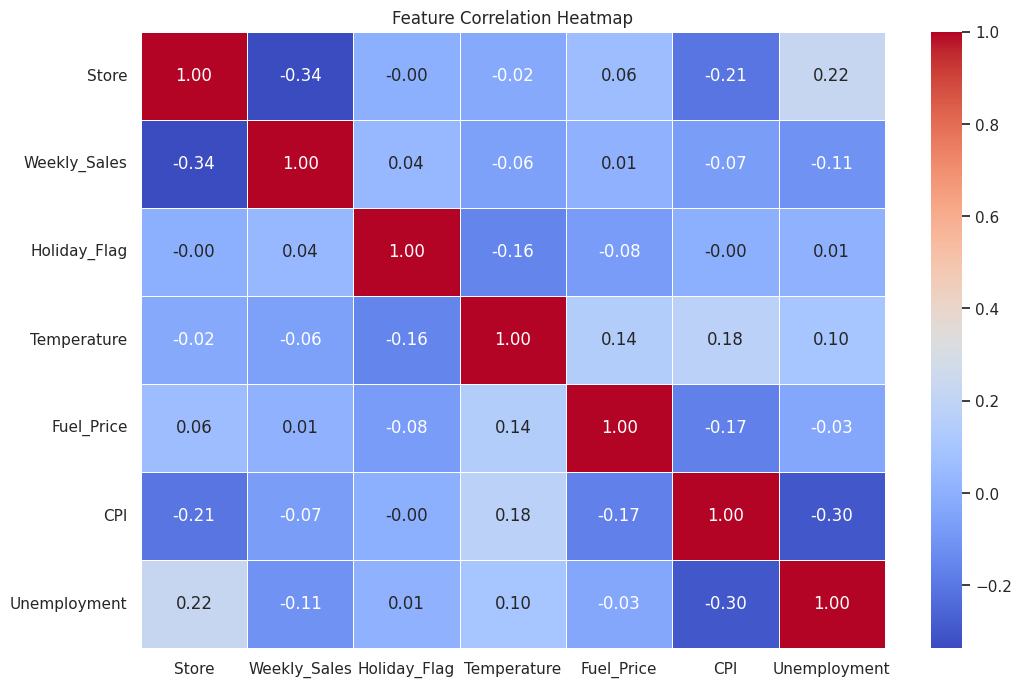

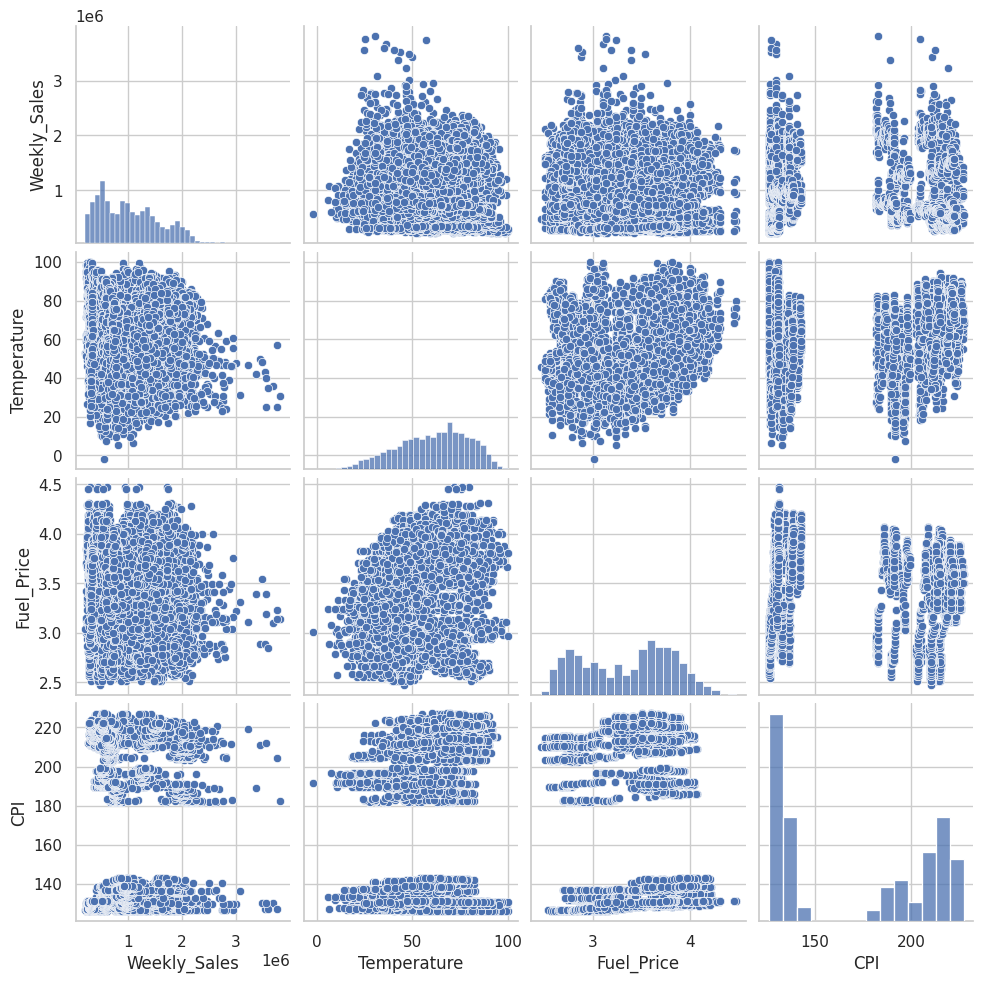

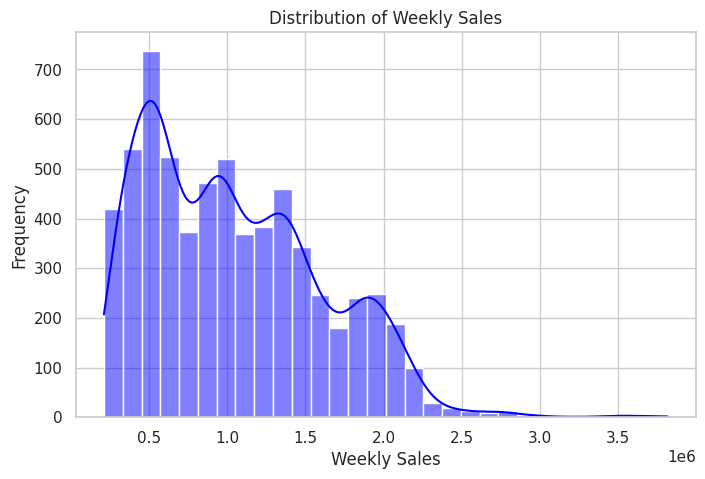

In [38]:
plt.figure(figsize=(12, 8))

df_numeric = df.select_dtypes(include=['number'])
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']])
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [39]:


# Define features (X) and target (y)
X = df.drop(columns=["Unemployment", "Date"])  # Drop both target and non-numeric 'Date' column
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1662
RMSE: 1.7227


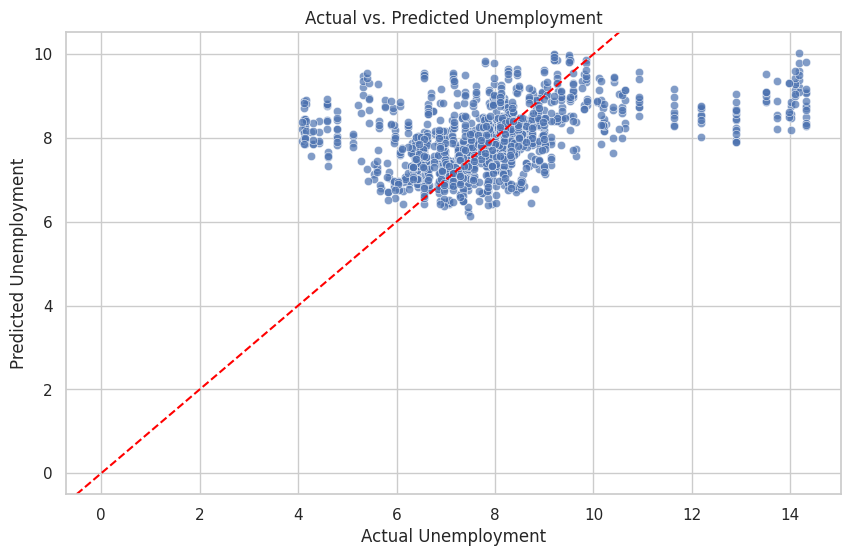

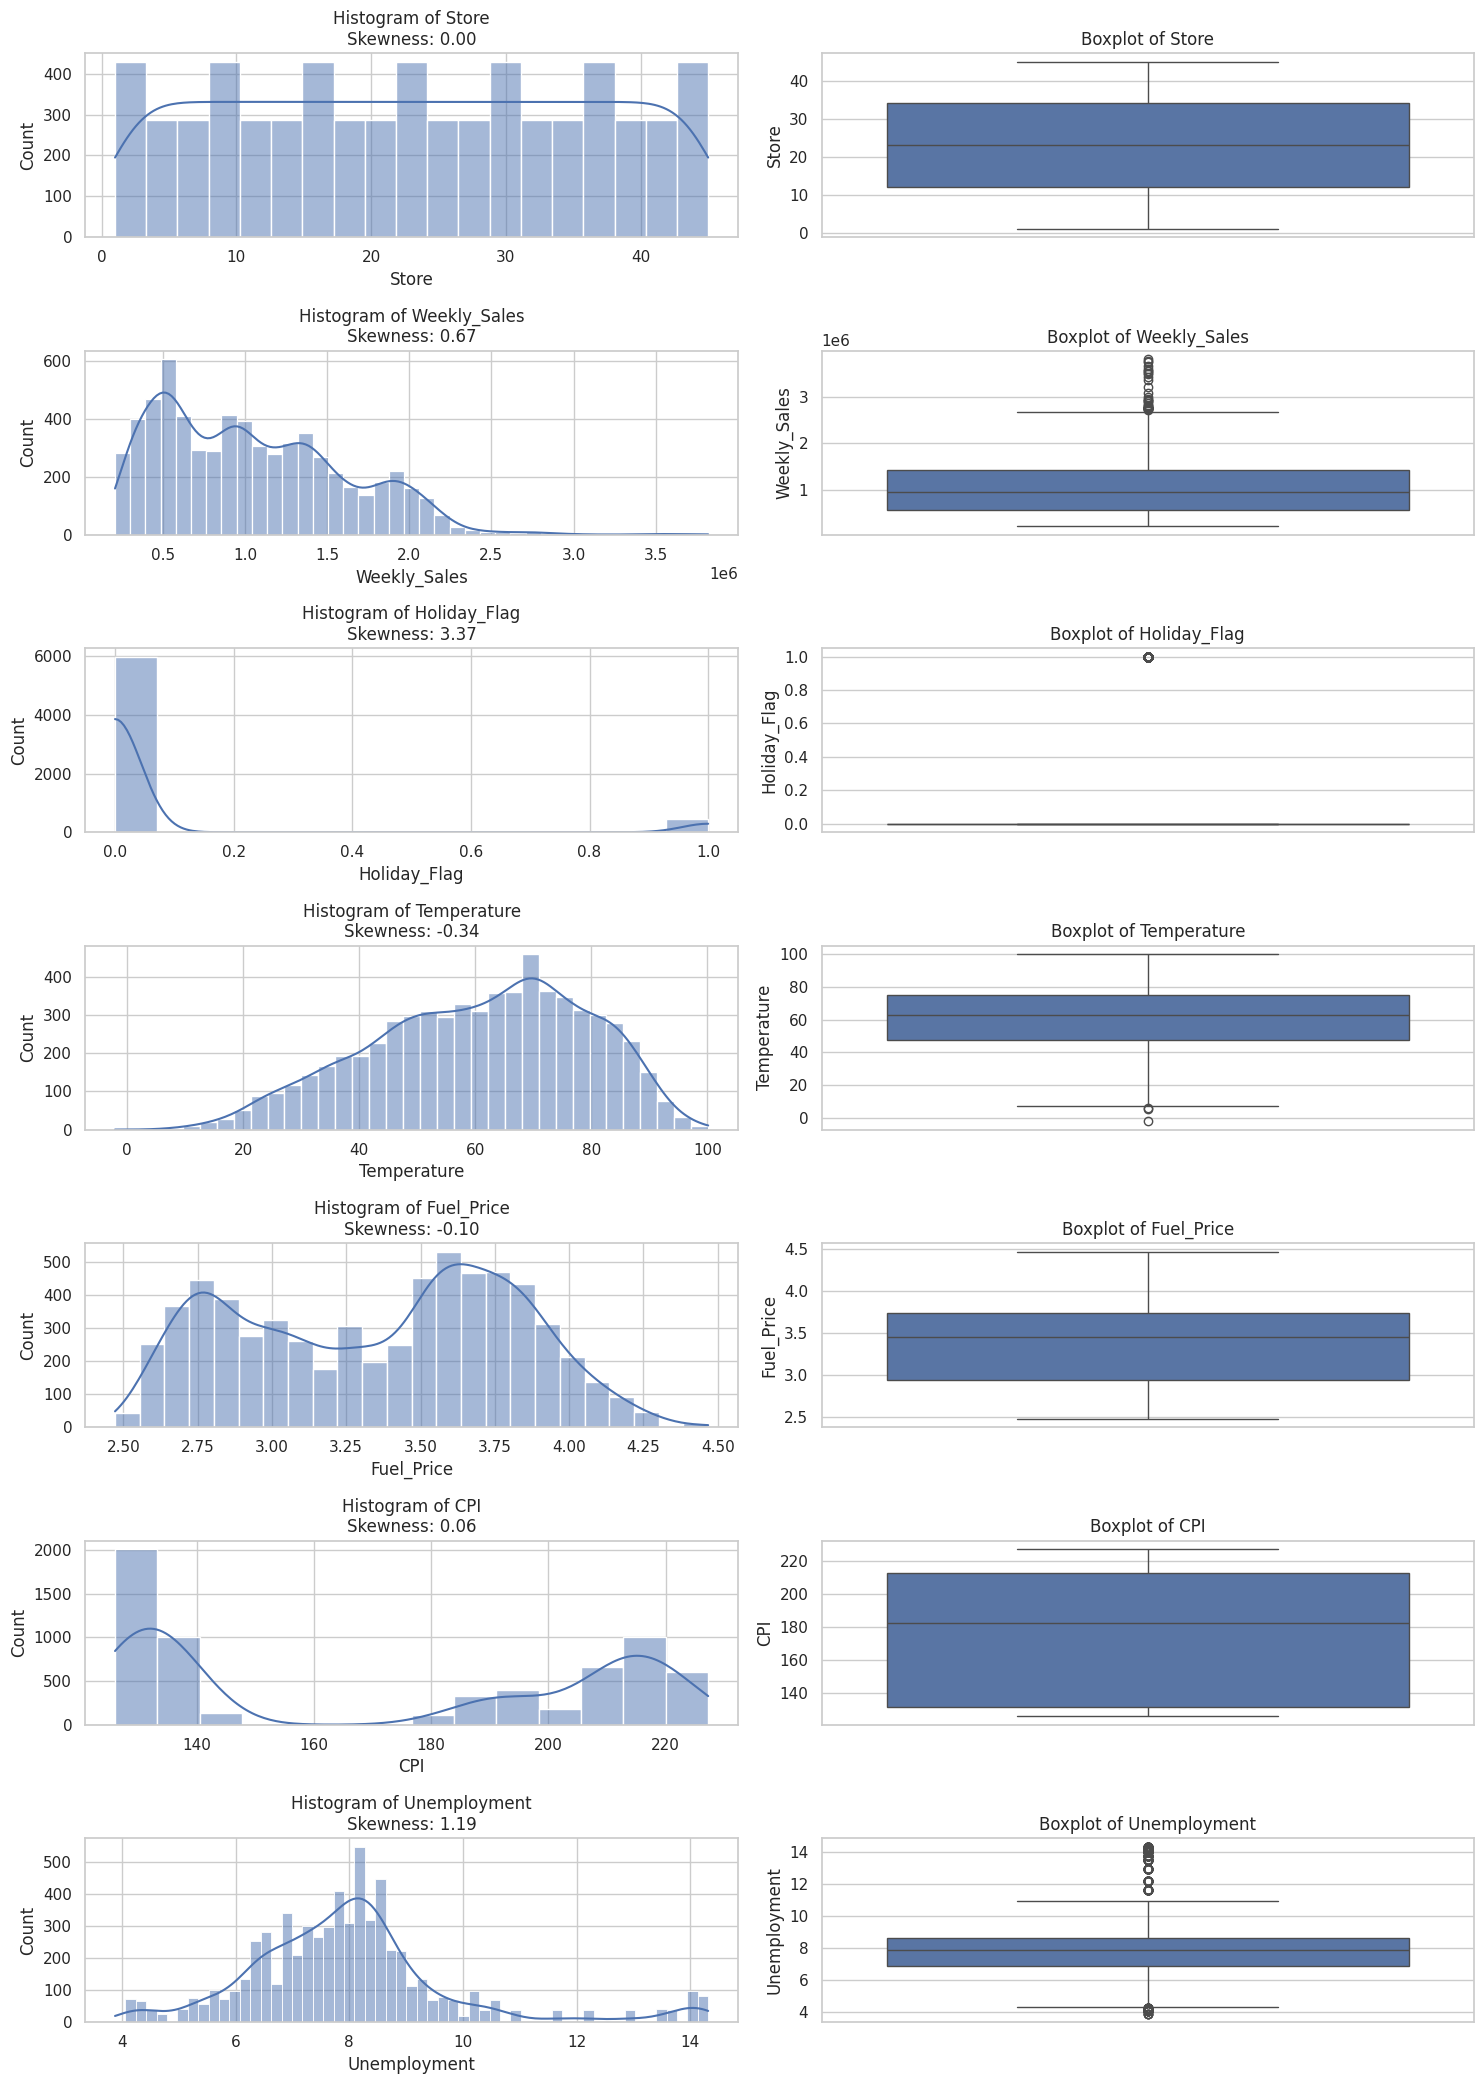

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Unemployment")
plt.ylabel("Predicted Unemployment")
plt.title("Actual vs. Predicted Unemployment")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

# Calculate skewness only for numerical columns
numerical_cols = df.select_dtypes(include=['number'])
skewness = numerical_cols.skew()

# Get the list of numerical columns for plotting
plot_cols = numerical_cols.columns

num_plot_cols = len(plot_cols)
plt.figure(figsize=(15,num_plot_cols*3))

for i,col in enumerate(plot_cols):
  plt.subplot(num_plot_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

  plt.subplot(num_plot_cols,2,2*i+2)
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [41]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df[['Day','Month','Year']]

,Day,Month,Year
0,5,2,2010
1,12,2,2010
2,19,2,2010
3,26,2,2010
4,5,3,2010
...,...,...,...
6430,28,9,2012
6431,5,10,2012
6432,12,10,2012
6433,19,10,2012


In [42]:

skewed_cols=df.select_dtypes(include=['number']).skew().abs()
highly_skewed = skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly skewed cols:")
print(highly_skewed)
print("negatively skewed cols:")
print(negatively_skewed)

Highly skewed cols:
Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed cols:
Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [43]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))
df[highly_skewed]

,Holiday_Flag,Unemployment
0,0.000000,2.208934
1,0.693147,2.208934
2,0.000000,2.208934
3,0.000000,2.208934
4,0.000000,2.208934
...,...,...
6430,0.000000,2.270475
6431,0.000000,2.268718
6432,0.000000,2.268718
6433,0.000000,2.268718


In [44]:


# Define features (X) and target (y)
X = df.drop(columns=["Unemployment", "Date"])  # Drop both target and non-numeric 'Date' column
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.2064
RMSE: 0.1784


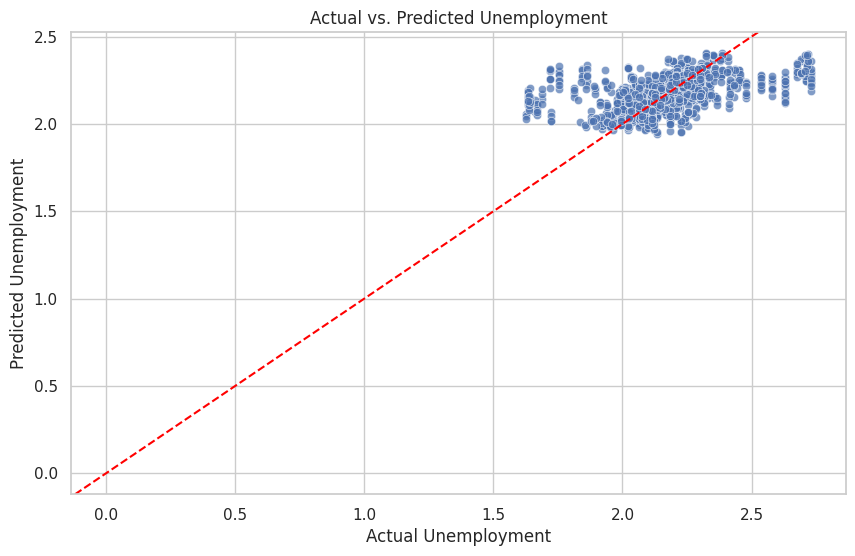

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Unemployment")
plt.ylabel("Predicted Unemployment")
plt.title("Actual vs. Predicted Unemployment")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()



In [46]:


#train random forest
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predictions
y_pred_rf=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred_rf)
rmse=mean_squared_error(y_test,y_pred_rf)**0.5

print(f"Random forest r2 score: {r2:.4f}")
print(f"Random forest RMSE: {rmse:.4f}")

Random forest r2 score: 0.9921
Random forest RMSE: 0.0178
